# 📊 People Analytics — Análisis de Rotación de Talento
### ABC Corporation · Data Analytics Project

---

## 🧠 Contexto de Negocio

A primera vista, la rotación de empleados en ABC Corporation no representa una señal de alarma. Sin embargo, las métricas globales no siempre reflejan lo que ocurre dentro de cada área de la empresa. Recursos Humanos detectó indicios de que la salida de empleados podría estar concentrándose en determinados puestos críticos, generando un impacto desproporcionado sobre la operación.

Este análisis nace para identificar dónde se produce realmente la fuga de talento, medir su magnitud y comprender qué variables están asociadas a ella. A través del análisis exploratorio de datos, el proyecto busca aportar una base objetiva para diseñar estrategias de retención más efectivas.

---

## 🗂️ Variables seleccionadas

Seleccionamos 8 variables que responden preguntas concretas de negocio:

| Variable | Pregunta de negocio |
|---|---|
| `department`, `jobrole` | ¿En qué parte de la empresa se concentra el problema? |
| `monthlyincome` | ¿El salario influye en la decisión de irse? |
| `yearsatcompany` | ¿Los empleados más nuevos son más vulnerables? |
| `jobsatisfaction` | ¿La satisfacción laboral protege contra la fuga? |
| `overtime` | ¿Las horas extras empujan a la salida? |
| `attrition` | ¿Quién se fue realmente? *(variable objetivo)* |

## ⚙️ 1. Librerías y Configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
sns.set_theme(style="whitegrid")

## 📂 2. Carga de Datos


In [15]:
# ── Carga del CSV ──────────────────────────────────────────────────────────
df = pd.read_csv("datasets/ABC_Corp.csv")

print("Columnas disponibles en el archivo original:")
print(df.columns.tolist())

Columnas disponibles en el archivo original:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [3]:
# ── Selección de variables relevantes ──────────────────────────────────────
columns_hr = [
    'EmployeeNumber',
    'Department', 'JobRole',
    'MonthlyIncome',
    'YearsAtCompany',
    'JobSatisfaction',
    'OverTime',
    'Attrition'
]

df = df[columns_hr].copy()
print(f"✅ Dataset listo: {df.shape[0]} empleados · {df.shape[1]} variables")

✅ Dataset listo: 1474 empleados · 8 variables


## 🔎 3. Calidad de Datos

Antes de describir ni analizar nada, necesitamos saber si los datos son fiables:
- ¿Hay errores tipográficos?
- ¿Hay duplicados?
- ¿Hay datos que faltan? (nulos que podrían sesgar los resultados)
- ¿Hay valores imposibles? (salario negativo, 80 años en la empresa)
- ¿Las escalas tienen sentido?

In [4]:
# ── Estandarización: snake_case y texto limpio ──────────────────────────────
df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.lower().str.strip().str.replace(" ", "_")

print("✅ Columnas y valores estandarizados a snake_case.")
print(f"Columnas actuales: {df.columns.tolist()}")

✅ Columnas y valores estandarizados a snake_case.
Columnas actuales: ['employeenumber', 'department', 'jobrole', 'monthlyincome', 'yearsatcompany', 'jobsatisfaction', 'overtime', 'attrition']


In [5]:
# ── Gestión de duplicados por ID de empleado ───────────────────────────────────────
total_duplicados = df.duplicated(subset=["employeenumber"]).sum()
pct_duplicados   = (total_duplicados / len(df)) * 100

print(f"🔍 Empleados repetidos: {total_duplicados} ({pct_duplicados:.2f}% del dataset)")

df.drop_duplicates(subset=["employeenumber"], keep="first", inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"✅ Dataset libre de duplicados: {df.shape[0]} empleados únicos.")

🔍 Empleados repetidos: 4 (0.27% del dataset)
✅ Dataset libre de duplicados: 1470 empleados únicos.


In [6]:
# ── Gestión de nulos ───────────────────────────────────────

# 1. Diagnóstico rápido: Ver nulos antes de tocar nada
print("⚠️ Estado inicial de nulos (Porcentaje):")
# Dividimos la suma de nulos entre el total de filas y multiplicamos por 100
porcentaje_nulos_inicial = (df[["monthlyincome", "jobsatisfaction", "department", "overtime"]].isnull().sum() / len(df)) * 100
print(porcentaje_nulos_inicial.map("{:.2f}%".format))
print("-" * 40)

filas_antes = len(df)

# 2. Imputación inteligente de nulos
df["monthlyincome"] = df["monthlyincome"].fillna(df.groupby("jobrole")["monthlyincome"].transform("median"))

columnas_moda = ["jobsatisfaction", "department", "overtime"]
for col in columnas_moda:
    df[col] = df[col].fillna(df[col].mode()[0])

# 3. Reporte final formal
filas_eliminadas = filas_antes - len(df)
nulos_finales = df[["monthlyincome", "jobsatisfaction", "department", "overtime"]].isnull().sum().sum()

# Calculamos el porcentaje real sobre el total de celdas analizadas
# (filas del dataframe multiplicado por las 4 columnas que estamos revisando)
total_celdas = len(df) * 4
porcentaje_nulos_final = (nulos_finales / total_celdas) * 100

print(f"✅ Tratamiento de nulos finalizado.")
print(f"   · Porcentaje de nulos restante: {porcentaje_nulos_final:.2f}%")

⚠️ Estado inicial de nulos (Porcentaje):
monthlyincome      0.95%
jobsatisfaction    1.97%
department         1.97%
overtime           2.99%
dtype: object
----------------------------------------
✅ Tratamiento de nulos finalizado.
   · Porcentaje de nulos restante: 0.00%


In [7]:
# ── Rango de valores: ¿son lógicos? ────────────────────────────────────────
variables_num = ["monthlyincome", "yearsatcompany", "jobsatisfaction"]

reporte = df[variables_num].agg(["min", "max", "median"]).T
reporte.columns = ["Mínimo", "Máximo", "Mediana"]

print("📐 Rango y mediana de variables numéricas:")
display(reporte.round(1))

📐 Rango y mediana de variables numéricas:


,Mínimo,Máximo,Mediana
monthlyincome,1009.0,19999.0,4907.0
yearsatcompany,0.0,40.0,5.0
jobsatisfaction,1.0,4.0,3.0


## 🏢 4A. ¿Cómo está estructurada la empresa?

Antes de buscar causas de la fuga, necesitamos entender **quiénes son** nuestros empleados
y cómo está organizada la plantilla. Las variables categóricas nos dicen dónde trabaja cada persona
y qué rol desempeña — son el mapa organizativo sobre el que luego leeremos el riesgo.

En este bloque **no cruzamos con attrition todavía** — solo describimos la realidad base.

In [8]:
# ── Distribución por Departamento y Puesto ──────────────────────────────────
print("🏢 DISTRIBUCIÓN POR DEPARTAMENTO")
display(df["department"].value_counts(normalize=True).mul(100).round(1).to_frame(name="%"))

print("💼 DISTRIBUCIÓN POR PUESTO / ROL")
display(df["jobrole"].value_counts(normalize=True).mul(100).round(1).to_frame(name="%"))

🏢 DISTRIBUCIÓN POR DEPARTAMENTO


,%
department,
research_&_development,65.9
sales,29.9
human_resources,4.3


💼 DISTRIBUCIÓN POR PUESTO / ROL


,%
jobrole,
sales_executive,22.2
research_scientist,19.9
laboratory_technician,17.6
manufacturing_director,9.9
healthcare_representative,8.9
manager,6.9
sales_representative,5.6
research_director,5.4
human_resources,3.5


## 📊 4B. ¿Cuál es el perfil económico y laboral del empleado típico?

Las variables numéricas nos describen las condiciones de trabajo: cuánto cobra, cuánto tiempo lleva
en la empresa y cómo valora su trabajo. Usamos la **mediana** como referencia
porque el salario y la antigüedad tienen outliers que distorsionarían la media.

In [9]:
print("📊 El empleado típico:")
display(df[["monthlyincome", "yearsatcompany", "jobsatisfaction"]].median().to_frame(name="Mediana").round(1))

📊 El empleado típico:


,Mediana
monthlyincome,4907.0
yearsatcompany,5.0
jobsatisfaction,3.0


## 🚨 4C. ¿Cómo de grave es el problema?

Antes de buscar causas, necesitamos dimensionar el problema: ¿qué porcentaje de la plantilla
está abandonando la empresa? Este dato es el punto de partida del análisis de riesgo.

> ⚠️ Un porcentaje global puede parecer moderado, pero ocultar segmentos críticos.
> Este número solo cobra sentido cuando lo cruzamos con los factores de riesgo.

In [10]:
# ── Tasa global de attrition ────────────────────────────────────────────────
# Este es el punto de partida del problema: ¿cómo de grave es la fuga?

print("📈 Tasa de Fuga General (Attrition):")
display(df["attrition"].value_counts(normalize=True).mul(100).round(1).to_frame(name="%"))

📈 Tasa de Fuga General (Attrition):


,%
attrition,
no,83.9
yes,16.1


## 🌡️ 5A. ¿Qué factores numéricos se asocian con la fuga?

El heatmap de correlación nos permite relacionar todas las variables numéricas con `attrition`
de un solo vistazo. Nos indica **en qué dirección y con qué intensidad** se mueve cada variable
respecto a la fuga.

**Cómo interpretar el resultado:**
| Valor | Significado |
|---|---|
| Cercano a **+1** | Cuando la variable sube, la fuga sube |
| Cercano a **-1** | Cuando la variable sube, la fuga baja |
| Cercano a **0** | Sin relación lineal apreciable |

**Referencia práctica en datos de RRHH:**
- `0.1 – 0.2` — débil, casi ruido
- `0.2 – 0.3` — moderada, vale la pena investigar
- `> 0.3` — relevante

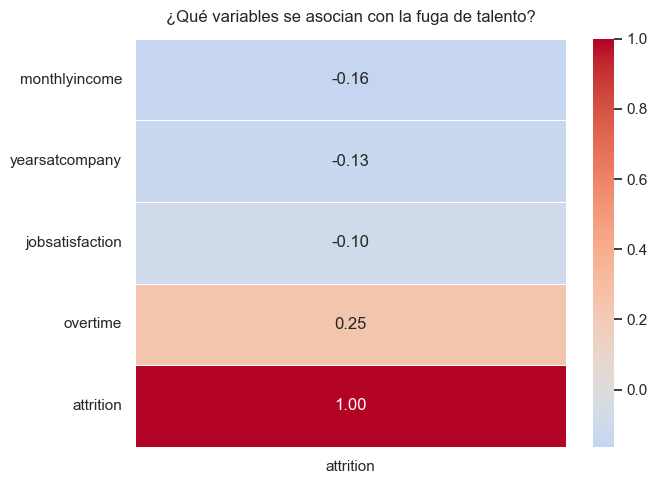

In [11]:
# ── Heatmap de correlación con attrition ────────────────────────────────────
df_corr = df[["monthlyincome", "yearsatcompany", "jobsatisfaction"]].copy()
df_corr["overtime"]  = (df["overtime"]  == "yes").astype(int)
df_corr["attrition"] = (df["attrition"] == "yes").astype(int)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    df_corr.corr()[["attrition"]].sort_values("attrition"),
    annot=True, fmt=".2f", cmap="coolwarm", center=0,
    linewidths=0.5, ax=ax
)
ax.set_title("¿Qué variables se asocian con la fuga de talento?", pad=12)
plt.tight_layout()
plt.show()

## 👥 5B. ¿A quién afecta la fuga?

Ahora cruzamos las variables categóricas con `attrition` para identificar
**en qué segmentos organizativos se concentra el riesgo**. También incluimos
`jobsatisfaction` aquí porque, aunque es numérica, su naturaleza ordinal
la hace más interpretable como categoría.

El orden importa: primero la dimensión actitudinal (¿cómo se siente el empleado?),
luego la estructural (¿dónde trabaja?).

In [12]:
# Dimensión actitudinal: ¿la satisfacción predice la salida?
print("😟 Tasa de Fuga por Nivel de Satisfacción Laboral (1=mínimo, 4=máximo):")
display(pd.crosstab(df["jobsatisfaction"], df["attrition"], normalize="index").mul(100).round(1))

😟 Tasa de Fuga por Nivel de Satisfacción Laboral (1=mínimo, 4=máximo):


attrition,no,yes
jobsatisfaction,,
1.0,77.4,22.6
2.0,83.3,16.7
3.0,83.6,16.4
4.0,88.2,11.8


In [13]:
# Dimensión estructural: ¿dónde se concentra el problema?
print("🏢 Tasa de Fuga por Departamento:")
display(pd.crosstab(df["department"], df["attrition"], normalize="index").mul(100).round(1).sort_values("yes", ascending=False))

print("\n💼 Tasa de Fuga por Puesto:")
display(pd.crosstab(df["jobrole"], df["attrition"], normalize="index").mul(100).round(1).sort_values("yes", ascending=False))

🏢 Tasa de Fuga por Departamento:


attrition,no,yes
department,,
sales,79.7,20.3
human_resources,81.0,19.0
research_&_development,86.0,14.0



💼 Tasa de Fuga por Puesto:


attrition,no,yes
jobrole,,
sales_representative,60.2,39.8
laboratory_technician,76.1,23.9
human_resources,76.9,23.1
sales_executive,82.5,17.5
research_scientist,83.9,16.1
healthcare_representative,93.1,6.9
manufacturing_director,93.1,6.9
manager,95.1,4.9
research_director,97.5,2.5


## ⏱️ 5C. ¿El desgaste por horas extra explica la fuga en los departamentos/puestos críticos?

El heatmap señaló `overtime` como uno de los factores con mayor asociación con la fuga.
Ahora necesitamos saber si ese desgaste se concentra precisamente en los departamentos/puesto
que ya identificamos como críticos — o si es un problema transversal a toda la empresa.


In [14]:
print("Horas Extra por Departamento (%):")
display(pd.crosstab(df["department"], df["overtime"], normalize="index").mul(100).round(1).sort_values("yes", ascending=False))

print("Horas Extra por Puesto (%):")
display(pd.crosstab(df["jobrole"], df["overtime"], normalize="index").mul(100).round(1).sort_values("yes", ascending=False))

Horas Extra por Departamento (%):


overtime,no,yes
department,,
sales,72.0,28.0
research_&_development,72.5,27.5
human_resources,74.6,25.4


Horas Extra por Puesto (%):


overtime,no,yes
jobrole,,
research_scientist,67.5,32.5
sales_representative,71.1,28.9
healthcare_representative,71.8,28.2
sales_executive,71.8,28.2
research_director,72.5,27.5
manager,73.5,26.5
manufacturing_director,74.5,25.5
human_resources,76.9,23.1
laboratory_technician,77.2,22.8


## 💡 6. ¿Qué factores explican la fuga y cómo actuar?

---

### Hallazgos principales

**Dimensión organizativa:**
- El departamento con mayor tasa de fuga es: `sales` (20.3%)
- El puesto más vulnerable es: `sales_representative` (39.8%)

**Dimensión actitudinal:**
- Los empleados con satisfacción muy baja (niveles 1) presenta tasa de fuga de 22.6%. 
- Los empleados muy satisfechos (nivel 4) tienen una tasa de fuga de solo 11.2%

**Dimensión de desgaste:**
- El overtime muestra una correlación de 0.25 con attrition — moderada/relevante
- El departamento `sales` con más overtime coincide con los de mayor fuga ( sales con un 28.6 %)
- El puesto más vulnerable es: `sales_representative`y es el segundo puesto con más horas extras

---

### Recomendaciones para RRHH

1. **No tomar decisiones sobre la tasa global** — el 16.1% de attrition general oculta segmentos
   donde la fuga es importante.
2. **Implementar una encuesta de satisfacción trimestral** para los puestos más vulnerables,
   usando los niveles 1-2 como umbral de alerta temprana
3. **Revisar la política de horas extra** en los departamentos críticos. 